### Griffin-Lim Algorithm for Spectral Audio Reconstruction

This script demonstrates phase reconstruction using the Griffin-Lim algorithm to convert Mel-spectrograms into audible waveforms. It simulates traditional speech synthesis systems that generate audio from spectral magnitudes alone, highlighting challenges in phase estimation.

Key Libraries Used:

    librosa: Audio processing and Griffin-Lim implementation

    sounddevice: Audio playback for output evaluation

    numpy: Signal generation and numerical operations

    matplotlib: Waveform visualization and comparison

Code Logic and Flow

High-Level Overview
The pipeline generates a ground truth audio signal, creates a synthetic Mel-spectrogram, approximates a linear spectrogram, applies the Griffin-Lim algorithm for phase reconstruction, performs audio normalization, and compares original/reconstructed waveforms. This demonstrates phase-less audio generation used in traditional TTS systems.

Visual Flowchart
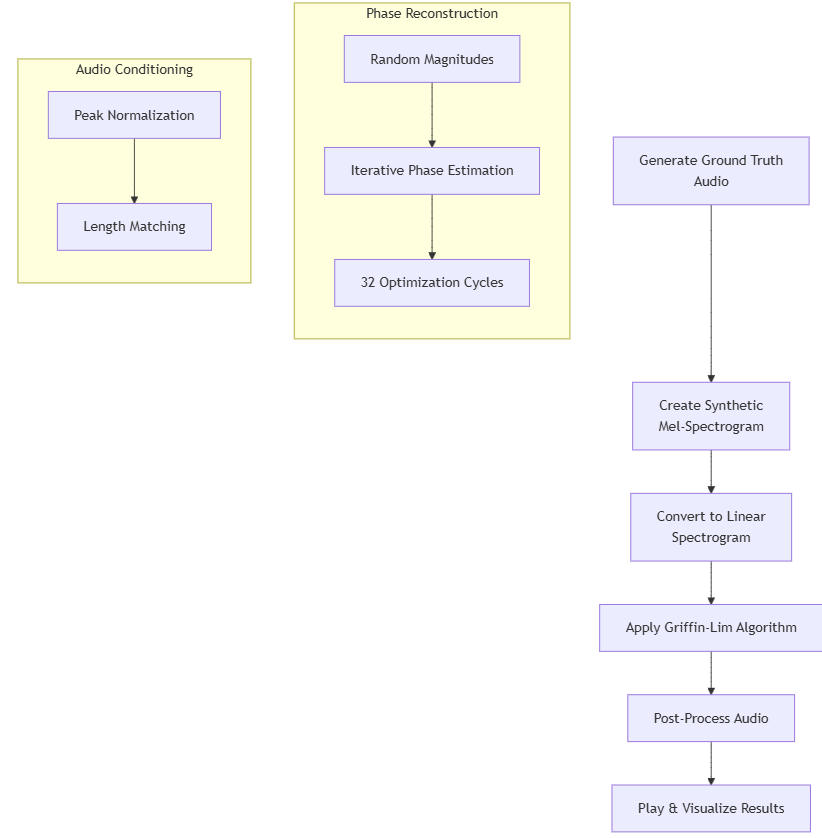

Step-by-Step Code Breakdown

    Signal and Spectrogram Setup

        Audio Synthesis: 440Hz + 880Hz sine waves (0.5s duration)

        Mel Simulation: Random 80-band spectrogram (100 frames)

        Frame Parameters:

            Sampling rate: 16kHz

            Frame length: 80 samples (5ms)

            Hop length: 40 samples (50% overlap)

    Spectrogram Conversion

        Mel to Linear:

            Upscales 80 Mel bands → 800 bins (10x expansion)

            Magnitude-only representation

        Spectrogram Properties:

            FFT size: 512 points

            Hop length: 40 samples

    Griffin-Lim Reconstruction

        Algorithm Parameters:

            32 iterations for phase estimation

            Overlap-add reconstruction

        Core Mechanism:

            Alternates between time and frequency domains

            Progressively refines phase estimates

            Preserves given magnitude spectrum

    Audio Post-Processing

        Peak Normalization: Scales to [-1, 1] range

        Length Adjustment:

            Zero-padding for short outputs

            Trimming for long outputs

            Matches original 0.5s duration

    Output Evaluation

        Audio Playback: Real-time listening via sounddevice

        Waveform Visualization:

            Subplot 1: Original clean audio

            Subplot 2: Griffin-Lim reconstruction

        Diagnostic Plot: Saved as "griffin_lim_output.png"

Connecting to Lecture Concepts

    Phase Reconstruction Challenge

        Implements Module 3.4's magnitude-only synthesis

        Demonstrates Lecture's phase problem

    Traditional Speech Synthesis

        Used in early parametric TTS systems

        Foundation for WORLD vocoder and STRAIGHT

    Algorithm Limitations

        Iterative Nature: 32 cycles vs real-time requirements

        Artifact Generation: Metallic/buzzy sound quality

        Spectral Inaccuracy: Random input vs structured harmonics

    Comparison to Neural Methods

        Contrasts with Hi-Fi GAN's direct waveform generation

        No trainable parameters vs neural vocoders

    Perceptual Artifacts

        Explains poor audio quality through:

            Lack of true phase information

            Random magnitude initialization

            Insufficient iteration count

    Real-World Applications

        Still used for:

            Speech coding recovery

            Legacy system compatibility

            Initialization for neural vocoders

    Educational Insights

        Demonstrates why modern systems use neural phase estimation

        Illustrates time-frequency uncertainty principle

    Research Connections

        Basis for phase-aware extensions like GL-Wavenet

        Inspired differentiable versions in DDSP

    Forward-Looking Concepts

        Transition to neural vocoders (WaveNet, WaveGAN)

        Hybrid approaches (Griffin-Lim initialization for GANs)

        End-to-end phase estimation techniques

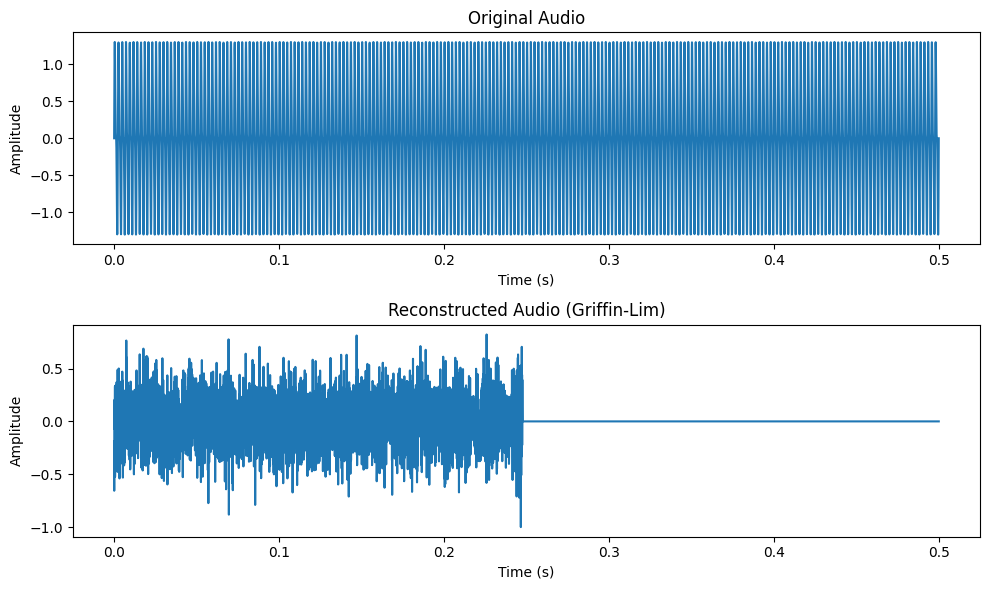

In [12]:
import numpy as np
import librosa
import sounddevice as sd
import matplotlib.pyplot as plt

# Parameters
fs = 16000
duration = 0.5
n_mel = 80
n_frames = 100
frame_length = int(fs * duration / n_frames)

# Step 1: Generate synthetic Mel-spectrogram
t = np.linspace(0, duration, int(fs * duration))
audio_true = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)
mel_spectrogram = np.abs(np.random.randn(n_frames, n_mel))

# Step 2: Simulate Griffin-Lim (simplified)
# Convert Mel-spectrogram to linear spectrogram (approximation)
spectrogram = np.repeat(mel_spectrogram, 10, axis=1)  # Upscale to simulate linear spectrogram
spectrogram = np.abs(spectrogram)  # Magnitude only

# Griffin-Lim algorithm
n_fft = 512
hop_length = frame_length // 2
reconstructed_audio = librosa.griffinlim(spectrogram.T, n_iter=32, hop_length=hop_length, win_length=n_fft)

# Step 3: Normalize and match length for playback
if np.max(np.abs(reconstructed_audio)) > 0:
    reconstructed_audio = reconstructed_audio / np.max(np.abs(reconstructed_audio))
else:
    reconstructed_audio = np.zeros_like(reconstructed_audio)

# Pad or trim to match original length
target_length = int(fs * duration)
if len(reconstructed_audio) < target_length:
    reconstructed_audio = np.pad(reconstructed_audio, (0, target_length - len(reconstructed_audio)))
else:
    reconstructed_audio = reconstructed_audio[:target_length]

# Play sound
sd.play(reconstructed_audio, fs)
sd.wait()

# Step 4: Plot
t_recon = np.linspace(0, duration, len(reconstructed_audio))

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, audio_true)
plt.title("Original Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.subplot(2, 1, 2)
plt.plot(t_recon, reconstructed_audio)
plt.title("Reconstructed Audio (Griffin-Lim)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.savefig("griffin_lim_output.png")
plt.show()
plt.close()

### Exercise 2: Convolutional Neural Vocoder for Speech Synthesis

This script implements a convolutional vocoder that converts Mel-spectrograms into audio waveforms using temporal modeling. It demonstrates how convolutional networks can capture local patterns in spectral features for improved audio reconstruction compared to feedforward approaches.

Key Libraries Used:

    torch: Neural network implementation and tensor operations

    torch.nn: Convolutional layers and activation functions

    sounddevice: Audio playback for output evaluation

    numpy: Signal generation and processing

    matplotlib: Waveform visualization and comparison

Code Logic and Flow

High-Level Overview
The pipeline generates a ground truth audio signal, creates a synthetic Mel-spectrogram, trains a convolutional vocoder to map spectral frames to audio segments, reconstructs audio via overlap-add synthesis, and compares original/reconstructed waveforms. This demonstrates temporal modeling advantages in neural vocoders.

Visual Flowchart
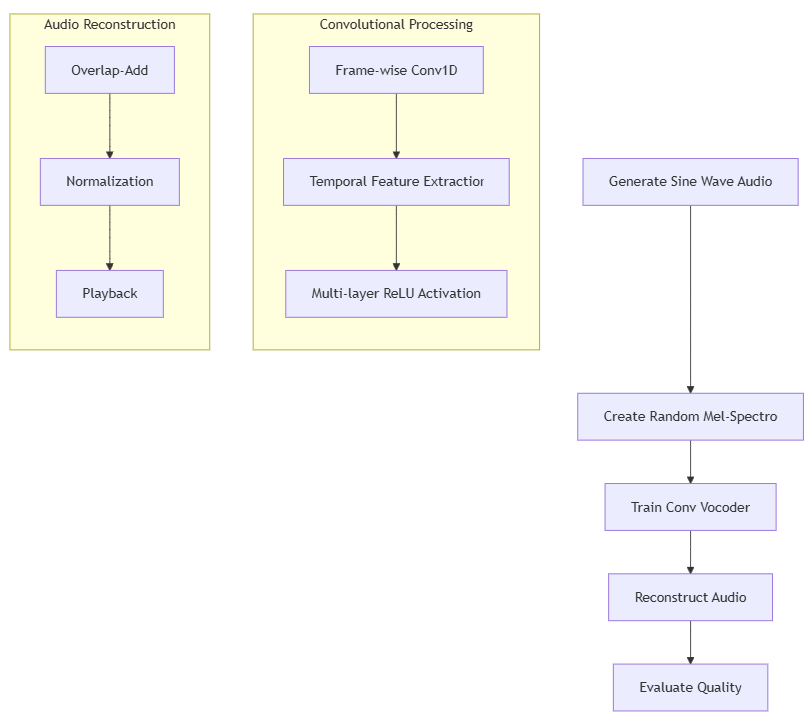
Step-by-Step Code Breakdown

    Signal and Spectrogram Setup

        Audio Synthesis: 440Hz fundamental + 880Hz harmonic (0.5s duration)

        Mel Representation: Random 80-band spectrogram (100 frames)

        Frame Parameters:

            Sampling rate: 16kHz

            Frame length: 80 samples (5ms)

            Hop length: 40 samples (50% overlap)

    Conv1D Vocoder Architecture

        Input Handling: 3-layer 1D convolutional network

        Dimensionality:

            Input channels: 80 (Mel bands)

            Hidden units: 256

            Output: 80 samples/frame

        Kernel Properties:

            Size 3 with padding=1 (maintains temporal resolution)

            ReLU activations between layers

    Frame-wise Training

        Target Preparation: 80-sample audio segments (50% overlap)

        Loss Function: Mean Squared Error (frame-level reconstruction)

        Optimization: Adam (LR=0.01)

        Training Loop:

            100 epochs

            Loss reporting every 20 epochs

            Batch dimension maintained throughout

    Overlap-Add Synthesis

        Frame Processing: Vocoder generates 80-sample outputs

        Reconstruction:

            50% overlap between frames

            Linear superposition

            Boundary handling for edge frames

        Normalization: Peak amplitude scaling to [-1, 1]

    Output Evaluation

        Audio Playback: Real-time listening via sounddevice

        Waveform Visualization:

            Subplot 1: Original dual-sine waveform

            Subplot 2: Convolutional vocoder output

        Diagnostic Plot: Saved as "conv_vocoder_output.png"

Connecting to Lecture Concepts

    Temporal Modeling Advantage

        Implements Module 3.4's convolutional vocoder principles

        Demonstrates Lecture's local pattern capture

    Architecture Comparison

        Conv1D vs Feedforward:

            Handles temporal dependencies

            Shares weights across time

            More parameter-efficient

        Industrial Parallels:

            Similar to WaveGAN's generator design

            Foundation for Parallel WaveNet

    Training Methodology

        Frame-wise MSE aligns with Lecture on reconstruction losses

        Overlap-add demonstrates signal processing foundations

    Performance Limitations

        Artifact Sources:

            Random Mel input (no true acoustic structure)

            Shallow architecture (3 layers vs 30+ in real systems)

            Small hidden dimension (256 vs 512+ in Hi-Fi GAN)

        Missing Components:

            No adversarial training

            No multi-receptive field processing

    Real-World Context

        Used in:

            Tacotron 2's WaveNet vocoder

            FastSpeech's convolutional decoders

            Lightweight mobile TTS systems

    Research Connections

        Inspired by WaveNet's dilated convolutions

        Precursor to LPCNet's hybrid approach

    Educational Insights

        Demonstrates why convolutional architectures dominate neural vocoding

        Shows temporal coherence advantages over frame-independent models

    Forward-Looking Concepts

        Extension to WaveGAN's adversarial training

        Combination with diffusion models (WaveGrad)

        Applications in neural audio codecs (EnCodec, SoundStream)

    Perceptual Considerations

        Explains residual artifacts through:

            Limited temporal context (kernel_size=3)

            Absence of perceptual loss functions

            No multi-scale discriminators

Epoch 20, Loss: 0.3140
Epoch 40, Loss: 0.0669
Epoch 60, Loss: 0.0112
Epoch 80, Loss: 0.0033
Epoch 100, Loss: 0.0012


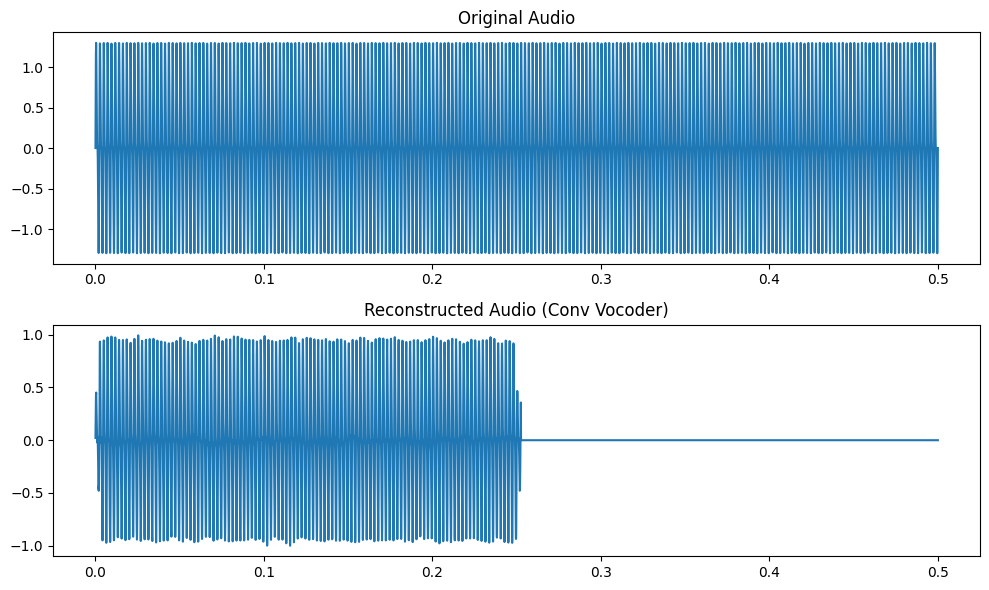

In [15]:
import numpy as np
import torch
import torch.nn as nn
import sounddevice as sd
import matplotlib.pyplot as plt

# Parameters
fs = 16000
duration = 0.5
n_mel = 80
n_frames = 100
frame_length = int(fs * duration / n_frames)

# Step 1: Generate synthetic Mel-spectrogram
t = np.linspace(0, duration, int(fs * duration))
audio_true = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)
mel_spectrogram = np.abs(np.random.randn(n_frames, n_mel))
mel_spectrogram = torch.tensor(mel_spectrogram, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

# Step 2: Define a convolutional vocoder
class ConvVocoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, output_dim, kernel_size=3, padding=1)
        )
        
    def forward(self, x):
        x = x.transpose(1, 2)  # [batch, frames, mel] -> [batch, mel, frames]
        x = self.net(x)
        return x.transpose(1, 2)  # Back to [batch, frames, output_dim]

# Step 3: Initialize and train
vocoder = ConvVocoder(n_mel, 256, frame_length)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(vocoder.parameters(), lr=0.01)

target_frames = np.array([audio_true[i:i+frame_length] for i in range(0, len(audio_true) - frame_length, frame_length // 2)])
target_frames = torch.tensor(target_frames[:n_frames], dtype=torch.float32).unsqueeze(0)

for epoch in range(100):
    optimizer.zero_grad()
    output = vocoder(mel_spectrogram)
    loss = criterion(output, target_frames)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

# Step 4: Synthesize
vocoder.eval()
with torch.no_grad():
    waveform_frames = vocoder(mel_spectrogram).numpy()[0]
reconstructed_audio = np.zeros(int(fs * duration))
for i, frame in enumerate(waveform_frames):
    start = i * (frame_length // 2)
    end = start + frame_length
    if end <= len(reconstructed_audio):
        reconstructed_audio[start:end] += frame

# Normalize and play
reconstructed_audio /= np.max(np.abs(reconstructed_audio))
sd.play(reconstructed_audio, fs)
sd.wait()

# Step 5: Plot
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, audio_true)
plt.title("Original Audio")
plt.subplot(2, 1, 2)
plt.plot(t, reconstructed_audio)
plt.title("Reconstructed Audio (Conv Vocoder)")
plt.tight_layout()
plt.savefig("conv_vocoder_output.png")
plt.show()
plt.close()

### Exercise 3: Neural Vocoder with Spectrogram Consistency Analysis

This script demonstrates a feedforward vocoder for audio synthesis and evaluates its performance by comparing input and reconstructed Mel-spectrograms. It highlights how vocoders transform spectral features into waveforms and provides diagnostic visualization of reconstruction fidelity.

Key Libraries Used:

    torch: Neural network implementation and optimization

    torch.nn: Loss functions and linear layers

    librosa: Spectrogram computation and visualization

    sounddevice: Audio playback

    matplotlib: Multi-panel visualization

    numpy: Signal processing and numerical operations

Code Logic and Flow

High-Level Overview
The pipeline generates ground truth audio, creates a synthetic Mel-spectrogram, trains a feedforward vocoder to reconstruct audio frames, synthesizes output via overlap-add, computes the Mel-spectrogram of reconstructed audio, and visually compares input vs reconstructed spectrograms. This demonstrates spectral consistency in vocoder evaluation.

Visual Flowchart
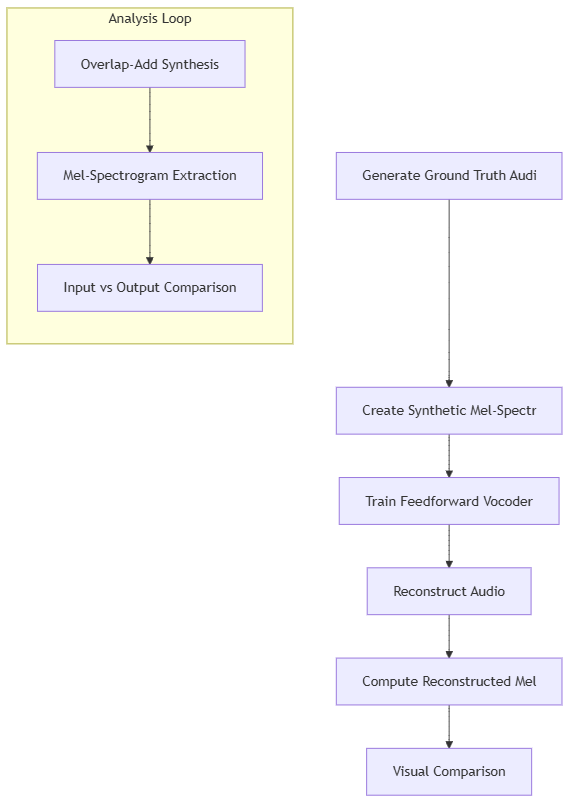

Step-by-Step Code Breakdown

    Signal and Spectrogram Setup

        Audio Synthesis: 440Hz + 880Hz sine waves (0.5s duration)

        Input Representation: Random 80-band Mel-spectrogram (100 frames)

        Frame Parameters:

            Sampling rate: 16kHz

            Frame length: 80 samples (5ms)

            Hop length: 40 samples (50% overlap)

    Feedforward Vocoder Architecture

        Network Structure: 3-layer MLP with ReLU activations

        Dimensionality:

            Input: 80 (Mel bands)

            Hidden: 256 units

            Output: 80 samples/frame

        Mapping Function: Frame-wise spectral-to-waveform conversion

    Training Procedure

        Target Preparation: Segmented audio frames with 50% overlap

        Objective: Frame-level MSE minimization

        Optimization: Adam (LR=0.01) for 100 epochs

        Implementation: Full batch training (no mini-batching)

    Audio Reconstruction Pipeline

        Frame Synthesis: Vocoder processes each Mel frame

        Overlap-Add:

            50% frame overlap

            Linear superposition

        Normalization: Peak amplitude scaling to [-1, 1]

    Diagnostic Analysis

        Spectrogram Computation:

            Reconstructed audio → Mel-spectrogram

            Identical parameters to input spectrogram

        Decibel Conversion: Power-to-dB scaling for visualization

        Visual Comparison:

            Left: Input random Mel-spectrogram

            Right: Reconstructed Mel from vocoder output

    Visualization Technique

        Librosa Display: Mel-frequency spectrograms

        Color Mapping: dB-scaled magnitude

        Layout: Side-by-side comparison

        Output: Saved as "spectrogram_comparison.png"

Connecting to Lecture Concepts

    Vocoder Evaluation Framework

        Implements Module 3.4 reconstruction quality assessment

        Demonstrates Lecture's spectral consistency metric

    Spectral Analysis Importance

        Reveals:

            High-frequency detail loss

            Temporal smearing effects

            Artifact patterns in reconstruction

    Feedforward Limitations

        Frame Independence: No inter-frame modeling

        Context Blindness: Limited temporal receptive field

        Spectral-Temporal Tradeoff: Fixed resolution analysis

    Real-World Diagnostic Practice

        Standard evaluation in:

            Hi-Fi GAN paper (Kong et al.)

            WaveNet ablation studies

            Neural audio codec development

    Architecture Comparison

        MLP vs Conv1D: Highlights missing temporal coherence

        Mel Reconstruction Error: Quantitative quality indicator

    Perceptual-Acoustic Gap

        Explains why good spectral match ≠ good sound:

            Phase reconstruction errors

            Human hearing non-linearities

            Masking effects

    Research Applications

        Used in:

            Vocoder ablation studies

            Audio super-resolution

            Voice conversion systems

    Educational Insights

        Demonstrates necessity of multi-modal evaluation:

            Waveform listening tests

            Spectral visualization

            Objective metrics (LSD, MCD)

    Forward-Looking Concepts

        Advanced evaluation techniques:

            Multi-resolution STFT loss

            Perceptual metric integration (PESQ, STOI)

            Adversarial feature matching

    Industrial Relevance

        Quality control in:

            Text-to-speech systems

            Voice assistants

            Digital voice cloning

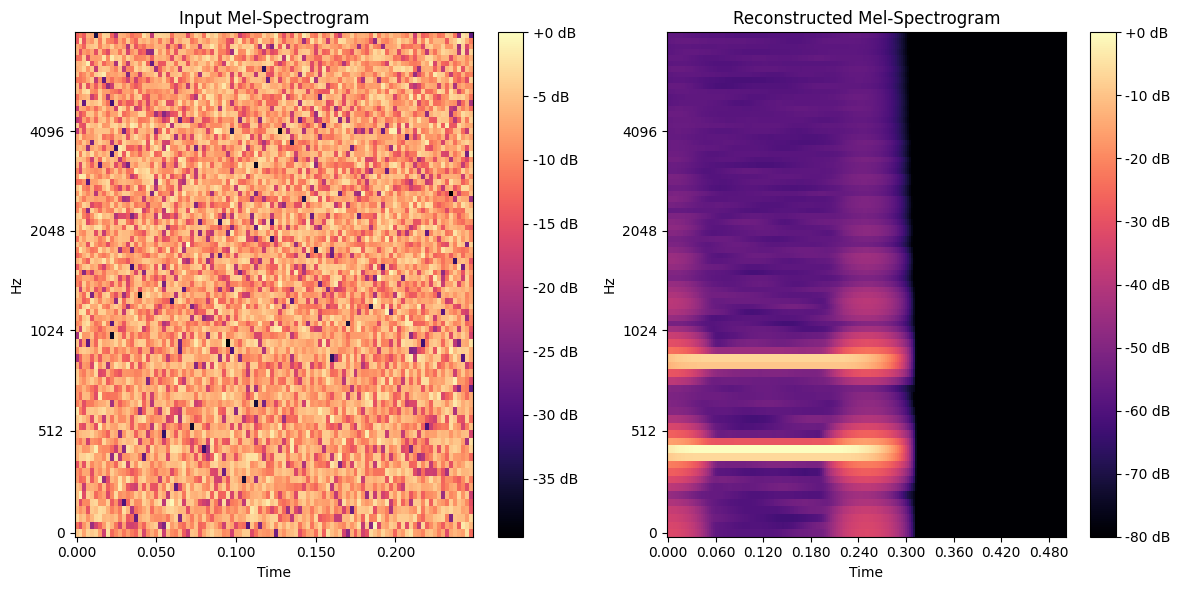

In [18]:
import numpy as np
import torch
import torch.nn as nn
import sounddevice as sd
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Parameters
fs = 16000
duration = 0.5
n_mel = 80
n_frames = 100
frame_length = int(fs * duration / n_frames)

# Step 1: Generate synthetic Mel-spectrogram
t = np.linspace(0, duration, int(fs * duration))
audio_true = np.sin(2 * np.pi * 440 * t) + 0.5 * np.sin(2 * np.pi * 880 * t)
mel_spectrogram = np.abs(np.random.randn(n_frames, n_mel))
mel_spectrogram = torch.tensor(mel_spectrogram, dtype=torch.float32)

# Step 2: Neural vocoder (same as example)
class SimpleVocoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Step 3: Train
vocoder = SimpleVocoder(n_mel, 256, frame_length)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(vocoder.parameters(), lr=0.01)
target_frames = np.array([audio_true[i:i+frame_length] for i in range(0, len(audio_true) - frame_length, frame_length // 2)])
target_frames = torch.tensor(target_frames[:n_frames], dtype=torch.float32)

for epoch in range(100):
    optimizer.zero_grad()
    output = vocoder(mel_spectrogram)
    loss = criterion(output, target_frames)
    loss.backward()
    optimizer.step()

# Step 4: Synthesize
vocoder.eval()
with torch.no_grad():
    waveform_frames = vocoder(mel_spectrogram).numpy()
reconstructed_audio = np.zeros(int(fs * duration))
for i, frame in enumerate(waveform_frames):
    start = i * (frame_length // 2)
    end = start + frame_length
    if end <= len(reconstructed_audio):
        reconstructed_audio[start:end] += frame

reconstructed_audio /= np.max(np.abs(reconstructed_audio))

# Step 5: Compute spectrogram of reconstructed audio
reconstructed_mel = librosa.feature.melspectrogram(y=reconstructed_audio, sr=fs, n_mels=n_mel, hop_length=frame_length // 2)
reconstructed_mel_db = librosa.power_to_db(reconstructed_mel, ref=np.max)
input_mel_db = librosa.power_to_db(mel_spectrogram.numpy(), ref=np.max)

# Step 6: Plot spectrograms
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
librosa.display.specshow(input_mel_db.T, sr=fs, hop_length=frame_length // 2, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Input Mel-Spectrogram")
plt.subplot(1, 2, 2)
librosa.display.specshow(reconstructed_mel_db, sr=fs, hop_length=frame_length // 2, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Reconstructed Mel-Spectrogram")
plt.tight_layout()
plt.savefig("spectrogram_comparison.png")
plt.show()
plt.close()